## Task 5: Model Explainability with Grad-CAM

In this task, you will investigate whether a supervised classification model focuses on clinically relevant regions of the knee X-ray images when predicting the osteoarthritis class. To this end, you will use Gradient-weighted Class Activation Mapping (Grad-CAM), a visualization technique that highlights image regions that contribute most strongly to the model's prediction.

Interpretability is particularly important in medical imaging, where high classification performance alone is not sufficient. In addition to predicting the correct label, it is desirable that the model bases its decision on meaningful anatomical structures, such as the joint space, osteophyte regions, or other visible signs of severe osteoarthritis. Furthermore, interpretability can provide insight into why the model fails on specific cases.

Create a new notebook named `GradCAM.ipynb`. Use one of your previously trained supervised models from Task 2 or Task 3.

### 1. Select a trained classifier
- Choose your best performing model from one of the previous tasks.
- Clearly indicate which model you use for this analysis.
- Reload the trained model and verify that it produces the expected predictions on the test set.

### 2. Implement Grad-CAM
- Apply Grad-CAM to a suitable convolutional layer of the selected model.
- Generate Grad-CAM heatmaps for a number of test images.
- Overlay the heatmaps on the original X-ray images for visualization.

### 3. Qualitative analysis
- Visualize Grad-CAM results for at least a few correctly classified healthy images and a few correctly classified severe osteoarthritis images.
- Additionally, visualize Grad-CAM results for some misclassified examples.
- Compare whether the highlighted regions differ between healthy and severe cases.

### 4. Clinical interpretation
- Analyze whether the model appears to focus on clinically meaningful regions, such as the knee joint space.
- Discuss whether the highlighted regions are plausible from a medical imaging perspective.
- Investigate whether there are examples where the model seems to focus on irrelevant structures or image artifacts.

---

In your report, briefly discuss the following aspects:

- **Interpretability method:** Describe the Grad-CAM method and explain on which model and layer it was applied.
- **Qualitative findings:** Summarize the main observations from the Grad-CAM visualizations.
- **Clinical relevance:** Discuss whether the model focuses on anatomically and clinically plausible regions.
- **Limitations:** Reflect on the limitations of Grad-CAM as an interpretability tool and explain why such visualizations should be interpreted with caution.

# 1. Select a Trained Classifier — Baseline CNN

We use the best-performing baseline CNN from Task 2 (lr=0.001, dropout=0.5, trained on train+val, 30 epochs).

In [1]:
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, accuracy_score
import os

In [3]:
from pipeline_helper import MyPreprocess

DATA_DIR = "../../data/1_source/"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyPreprocess()
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [4]:
from model_helper import BaselineCNN

MODEL_PATH = "../2_basemodel/baseline_model.pth"
model = BaselineCNN.load(MODEL_PATH, device)
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9452
F1 Score: 0.9184


In [6]:
# setting the global colors and labels used for analysis
CLASS_VALUES = [0, 1]
CLASS_NAMES = ["Healthy", "OA"]
CLASS_COLORS = ["blue", "red"]

# 2. Implement Grad-CAM

We use the **[pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam)** library, which provides a battle-tested implementation with support for GradCAM, GradCAM++, ScoreCAM and more.

Grad-CAM computes a heatmap by:
1. Performing a forward pass to obtain the model output.
2. Back-propagating the output score to a chosen convolutional layer.
3. Global-average-pooling the gradients over the spatial dimensions to get per-channel weights.
4. Taking the ReLU of the weighted sum of the feature maps — keeping only regions that positively contribute to the prediction.

We target `model.gradcam_layer` — the ReLU after the last Conv2d block, which produces 32×32 feature maps and is the deepest spatially-resolved activation before global pooling.

In [7]:
!pip install grad-cam

In [8]:
from pytorch_grad_cam import GradCAM

In [9]:
from pipeline_helper import MyToTensor

display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyToTensor()
)

grad_cam = GradCAM(model=model, target_layers=[model.gradcam_layer])
print("GradCAM target: model.gradcam_layer (last conv ReLU, feature map 32×32)")

GradCAM target: model.gradcam_layer (last conv ReLU, feature map 32×32)


In [ ]:
from img_helper import show_images


# printing functions
def overlay_heatmap(img_tensor, cam, alpha=0.5) -> np.ndarray:
    """
    Blend a Grad-CAM heatmap onto a grayscale image tensor.
    img_tensor : (1, H, W) float tensor in [0, 1]
    cam        : (H, W) numpy array in [0, 1]
    Returns    : (H, W, 3) numpy array ready for imshow
    """
    img_np = img_tensor.squeeze().numpy()
    H, W = img_np.shape

    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_t, size=(H, W), mode="bilinear", align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    heatmap = plt.colormaps["jet"](cam_up)[:, :, :3]
    img_rgb = np.stack([img_np] * 3, axis=-1)
    return np.clip(alpha * heatmap + (1 - alpha) * img_rgb, 0, 1)


def show_gradcam(
    indices,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    class_names,
    device,
    title="",
    n=5,
) -> None:
    """
    Plot Grad-CAM results: original image (top) + heatmap overlay (bottom) per column.
    Delegates grid layout and titling to show_images.
    """
    indices = indices[:n]
    overlays = []
    for idx in indices:
        img_display, _ = display_dataset[idx]
        img_tensor, _ = test_dataset[idx]
        grayscale = grad_cam(
            input_tensor=img_tensor.unsqueeze(0).to(device), targets=None
        )
        overlays.append(overlay_heatmap(img_display, grayscale[0]))

    show_images(
        indices,
        display_dataset,
        all_labels=all_labels,
        all_preds=all_preds,
        all_probs=all_probs,
        class_names=class_names,
        title=title,
        overlays=overlays,
    )

# 3. Qualitative Analysis

In [ ]:
correct_healthy = np.where(
    (all_labels == CLASS_VALUES[0]) & (all_preds == CLASS_VALUES[0])
)[0]
correct_oa = np.where((all_labels == CLASS_VALUES[1]) & (all_preds == CLASS_VALUES[1]))[
    0
]
misclassified = np.where(all_labels != all_preds)[0]

print(f"Correctly classified {CLASS_NAMES[0]}: {len(correct_healthy)}")
print(f"Correctly classified {CLASS_NAMES[1]}     : {len(correct_oa)}")
print(f"Misclassified              : {len(misclassified)}")

Correctly classified Healthy: 93
Correctly classified OA     : 45
Misclassified              : 8


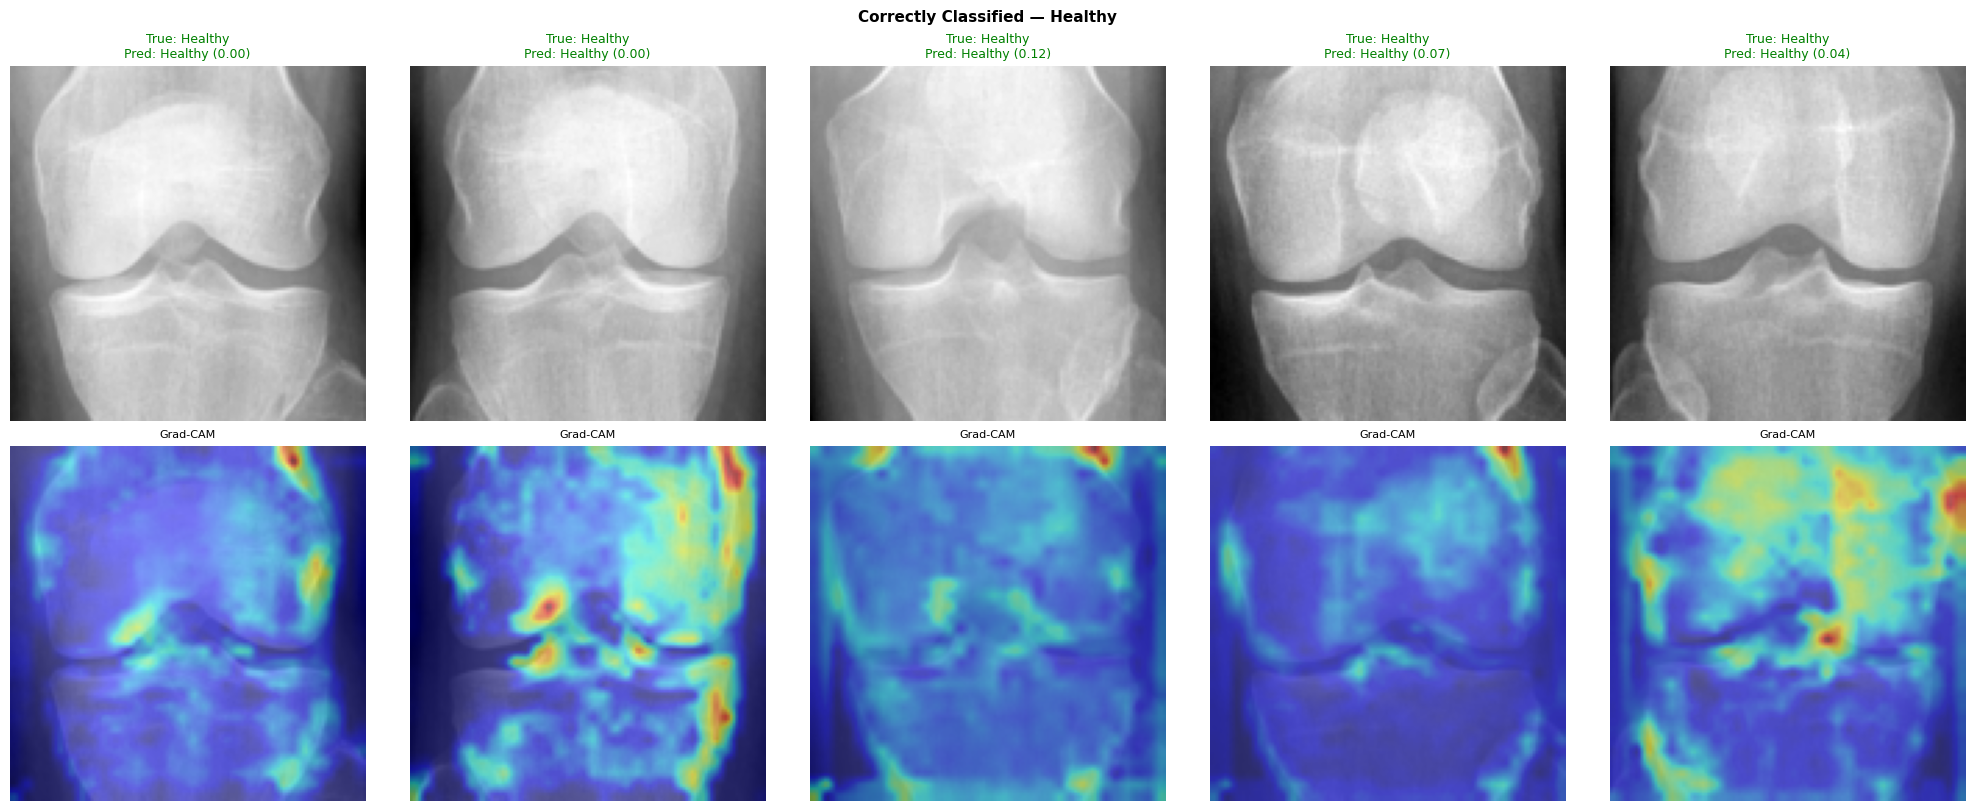

In [ ]:
show_gradcam(
    correct_healthy,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title=f"Correctly Classified — {CLASS_NAMES[0]}",
)

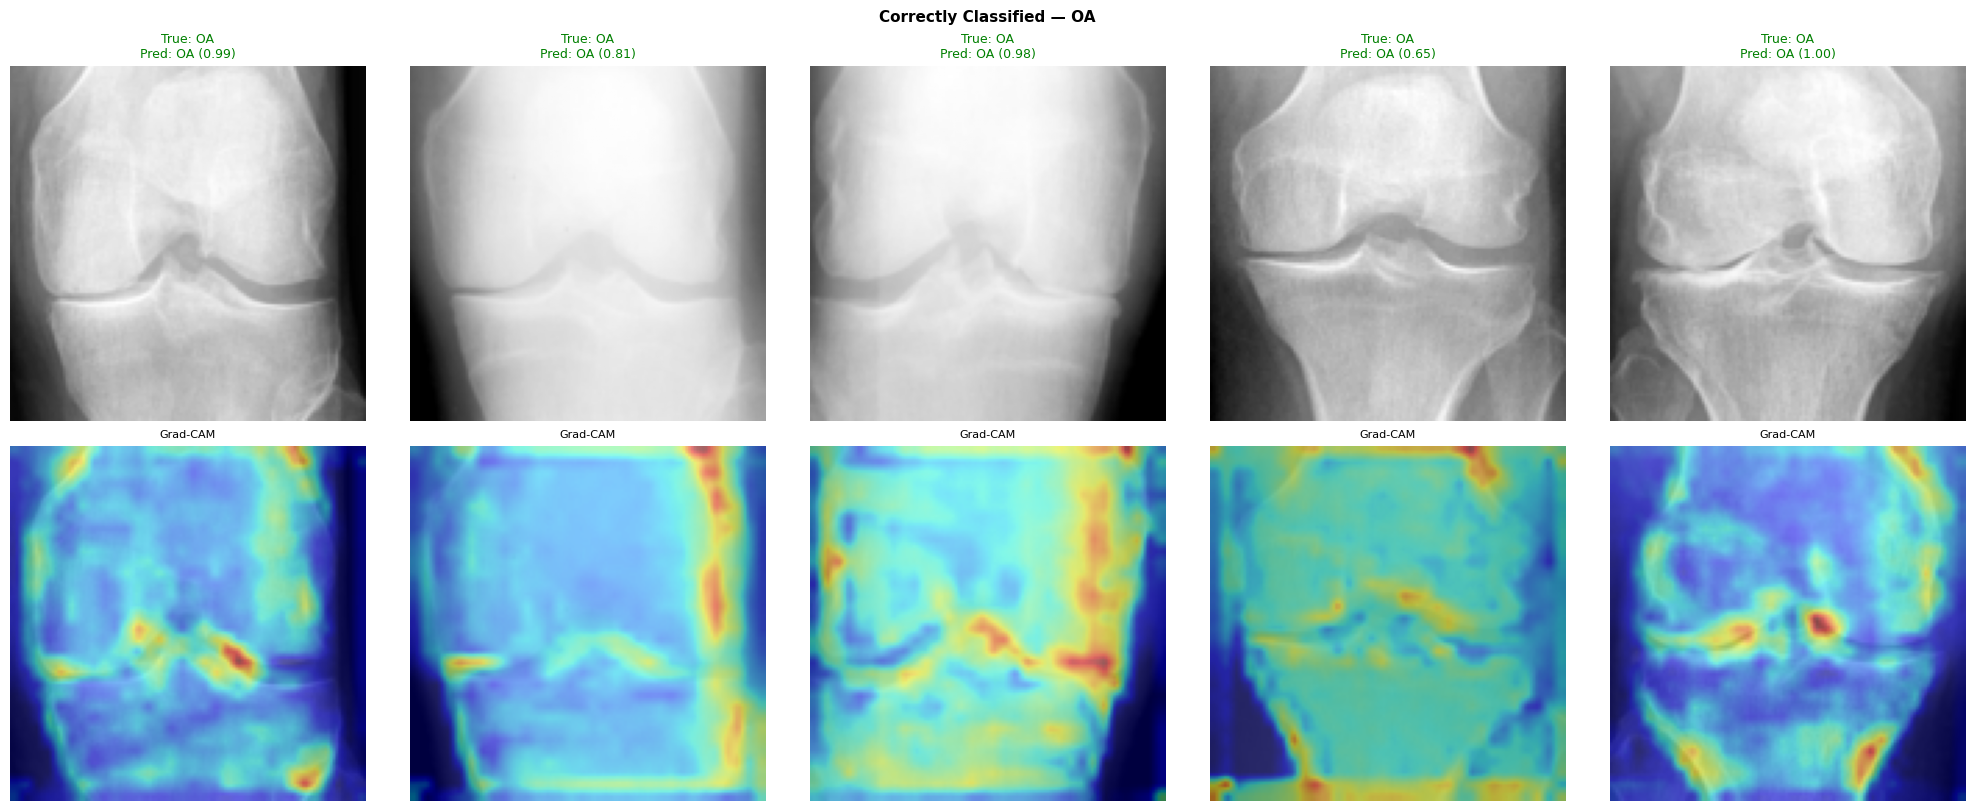

In [ ]:
show_gradcam(
    correct_oa,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title=f"Correctly Classified — {CLASS_NAMES[1]}",
)

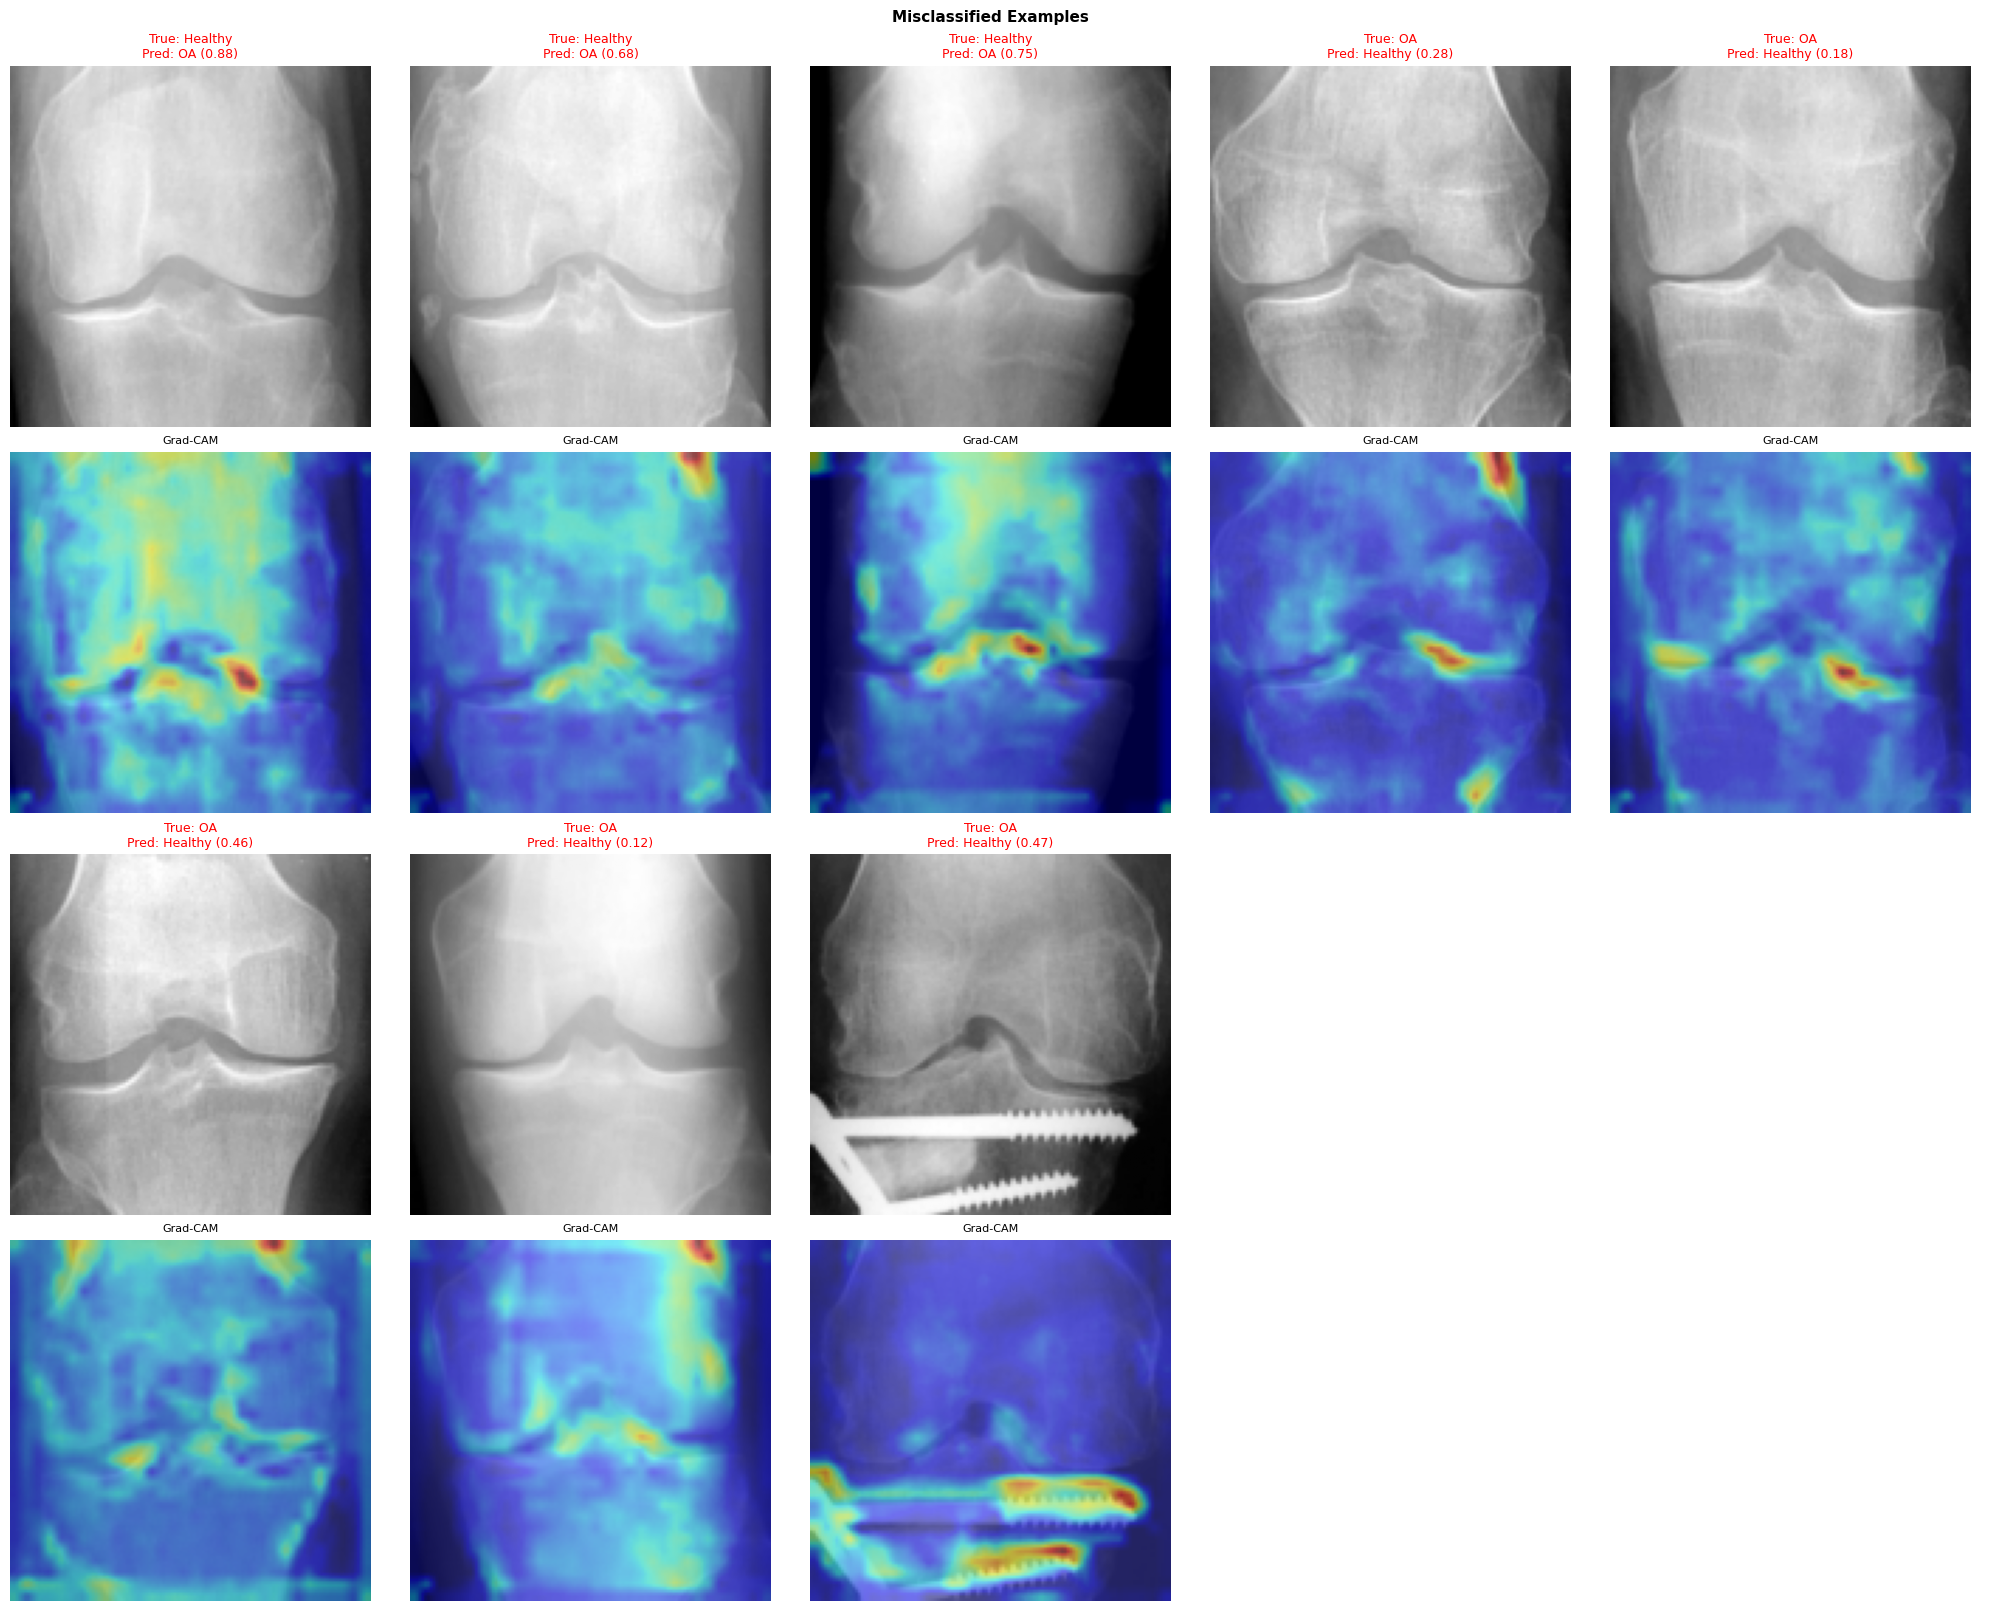

In [ ]:
show_gradcam(
    misclassified,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Misclassified Examples",
    n=50,
)

# 4. Clinical Interpretation

In knee OA X-rays the clinically relevant region is the **knee joint space** — the gap between femur and tibia, visible as a bright horizontal band in the vertical centre of the image.

We quantify clinical relevance with two spatial statistics computed on each Grad-CAM heatmap:

---

### Central-band activation fraction
The image is split into three equal horizontal bands (top / middle / bottom, each 43 rows tall at 128 px):

```
row   0 ┌──────────────┐
         │   top third  │  (irrelevant — femur shaft, soft tissue)
row  43 ├──────────────┤
         │ MIDDLE THIRD │  ← joint space lives here
row  85 ├──────────────┤
         │ bottom third │  (irrelevant — tibia shaft)
row 127 └──────────────┘
```

The metric is:

> **central-band fraction = (sum of Grad-CAM activation in rows 43–85) / (total activation)**

Interpretation:
- **= 1/3 ≈ 0.33** → activation is spread uniformly — the model looks everywhere equally (random baseline)
- **> 1/3** → the model attends *more* to the joint space than chance; clinically plausible
- **< 1/3** → the model is actively avoiding the joint space; activations are in the periphery

---

### Vertical centre of mass (CoM)
The activation-weighted average row position, rescaled so **0 = bottom of image, 1 = top, 0.5 = centre**.

A CoM near 0.5 means the "centre of gravity" of the heatmap sits at the middle of the image — again consistent with joint-space focus.

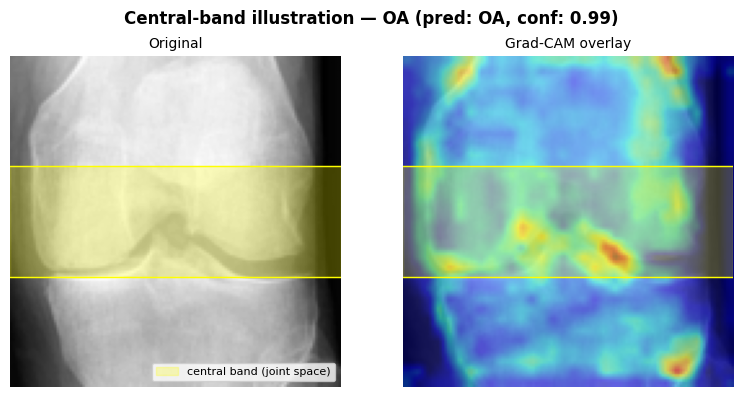

In [ ]:
# Illustrate where the central band sits on a real example image + its Grad-CAM heatmap
example_idx = correct_oa[0]
img_display, _ = display_dataset[example_idx]
img_tensor, _ = test_dataset[example_idx]

grayscale = grad_cam(input_tensor=img_tensor.unsqueeze(0).to(device), targets=None)
cam_ex = grayscale[0]


overlay = overlay_heatmap(img_display, cam_ex)

H = img_display.shape[-1]
r1, r2 = H // 3, 2 * H // 3
band_color, band_alpha = "yellow", 0.25

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (im, label) in zip(
    axes, [(img_display.squeeze().numpy(), "Original"), (overlay, "Grad-CAM overlay")]
):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.axhspan(
        r1, r2, color=band_color, alpha=band_alpha, label="central band (joint space)"
    )
    ax.axhline(r1, color=band_color, linewidth=1)
    ax.axhline(r2, color=band_color, linewidth=1)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(
    f"Central-band illustration — {CLASS_NAMES[int(all_labels[example_idx])]} "
    f"(pred: {CLASS_NAMES[int(all_preds[example_idx])]}, conf: {all_probs[example_idx]:.2f})",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# Run GradCAM on every test image and collect spatial statistics
cam_stats = []

for idx in range(len(test_dataset)):
    img_tensor, _ = test_dataset[idx]
    img_input = img_tensor.unsqueeze(0).to(device)

    grayscale = grad_cam(input_tensor=img_input, targets=None)
    cam = grayscale[0]  # (H, W), normalised to [0, 1]

    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_t, size=(128, 128), mode="bilinear", align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    H, W = cam_up.shape
    total = cam_up.sum() + 1e-8

    r1, r2 = H // 3, 2 * H // 3  # rows 43–85, which is the middle third of the image
    center_frac = cam_up[r1:r2, :].sum() / total

    # vertical CoM: 0 = bottom, 1 = top, 0.5 = centre
    y_idx = 1 - np.arange(H).reshape(-1, 1) / (H - 1)
    com_y = (cam_up * y_idx).sum() / total

    cam_stats.append(
        {
            "idx": idx,
            "center_frac": float(center_frac),
            "com_y": float(com_y),
            "label": int(all_labels[idx]),
            "pred": int(all_preds[idx]),
        }
    )

center_frac_arr = np.array([s["center_frac"] for s in cam_stats])
com_y_arr = np.array([s["com_y"] for s in cam_stats])
class_masks = [all_labels == cls for cls in CLASS_VALUES]

for mask, name in zip(class_masks, CLASS_NAMES):
    print(f"Mean central-band fraction  — {name}: {center_frac_arr[mask].mean():.3f}")
    print(f"Mean vertical CoM (0.5=mid) — {name}: {com_y_arr[mask].mean():.3f}")

Mean central-band fraction  — Healthy: 0.328
Mean vertical CoM (0.5=mid) — Healthy: 0.543
Mean central-band fraction  — OA: 0.350
Mean vertical CoM (0.5=mid) — OA: 0.521


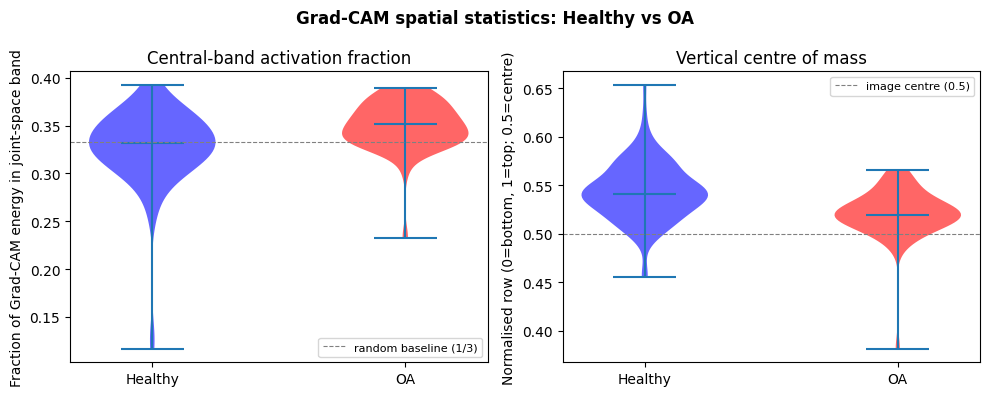

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

datasets_info = [
    (
        center_frac_arr,
        "Central-band activation fraction",
        "Fraction of Grad-CAM energy in joint-space band",
        1 / 3,
        "random baseline (1/3)",  # a uniform heatmap would score 1/3
    ),
    (
        com_y_arr,
        "Vertical centre of mass",
        "Normalised row (0=bottom, 1=top; 0.5=centre)",
        0.5,
        "image centre (0.5)",
    ),
]

for ax, (values, title, ylabel, ref, ref_label) in zip(axes, datasets_info):
    data = [values[mask] for mask in class_masks]
    parts = ax.violinplot(data, positions=CLASS_VALUES, showmedians=True)

    for pc, color in zip(parts["bodies"], CLASS_COLORS):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    ax.set_xticks(CLASS_VALUES)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(ref, color="gray", linestyle="--", linewidth=0.8, label=ref_label)
    ax.legend(fontsize=8)

plt.suptitle(
    f"Grad-CAM spatial statistics: {' vs '.join(CLASS_NAMES)}", fontweight="bold"
)
plt.tight_layout()
plt.show()

so given our result now, the model is not performing OK, the central band activation is based on chance for healthy, and just little more focused on the centerband for OA. On top of that we also see bottom outliers, meaning the central band is nearly unused in those cases.
Fot the central mass we notice that healtly is more focusing on the top of the image, OA is more towards the center, but then shows bottom outliers which are explained by the attention on the foreign objects.(screws and bolts)

### Discussion

#### Central-band activation fraction
| Class | Mean | vs baseline (1/3) |
|---|---|---|
| Healthy | ~0.33 | ≈ at chance |
| OA | ~0.35 | marginally above chance |

Both classes score close to the random baseline of 1/3, meaning the model's attention is broadly spread across the full image rather than concentrated on the joint space. For **Healthy** images the model is essentially guessing spatially — it achieves high classification accuracy through cues distributed across the whole X-ray, not by isolating the joint gap. **OA** shows a slight improvement but the effect is small and clinically insufficient.

Both distributions also show **low-end outliers** (fractions well below 1/3), meaning for a subset of images the central band is almost entirely ignored — the model's decisive features lie in the periphery.

#### Vertical centre of mass
| Class | Mean CoM | Interpretation |
|---|---|---|
| Healthy | ~0.54 | attention pulled toward the **top** of the image |
| OA | ~0.52 | closer to centre, but still slightly above |

Healthy predictions are driven by features in the upper region of the X-ray (femur shaft / soft tissue above the joint), which are not clinically meaningful for OA grading. OA predictions sit nearer the centre, consistent with some joint-space attention, but not reliably so.

**OA bottom outliers**: a cluster of OA images shows CoM near 0 (very bottom of the image). These correspond to X-rays containing **foreign objects (screws / bolts)** from prior surgery — the model latches onto those metallic artefacts rather than the joint space, which is a clear example of spurious feature reliance.

#### Conclusion
The model achieves high accuracy (~94%) but for the wrong reasons: it exploits texture and structural cues distributed across the whole image rather than focusing on the anatomically relevant joint space. This is a known failure mode of CNNs trained on small medical datasets without spatial supervision. Grad-CAM here provides a meaningful warning that the model would likely not generalise to images from a different scanner or patient population where those peripheral cues differ.

Central-band fractions for lowest-focus images: [0.116 0.135 0.233 0.25  0.26  0.275]


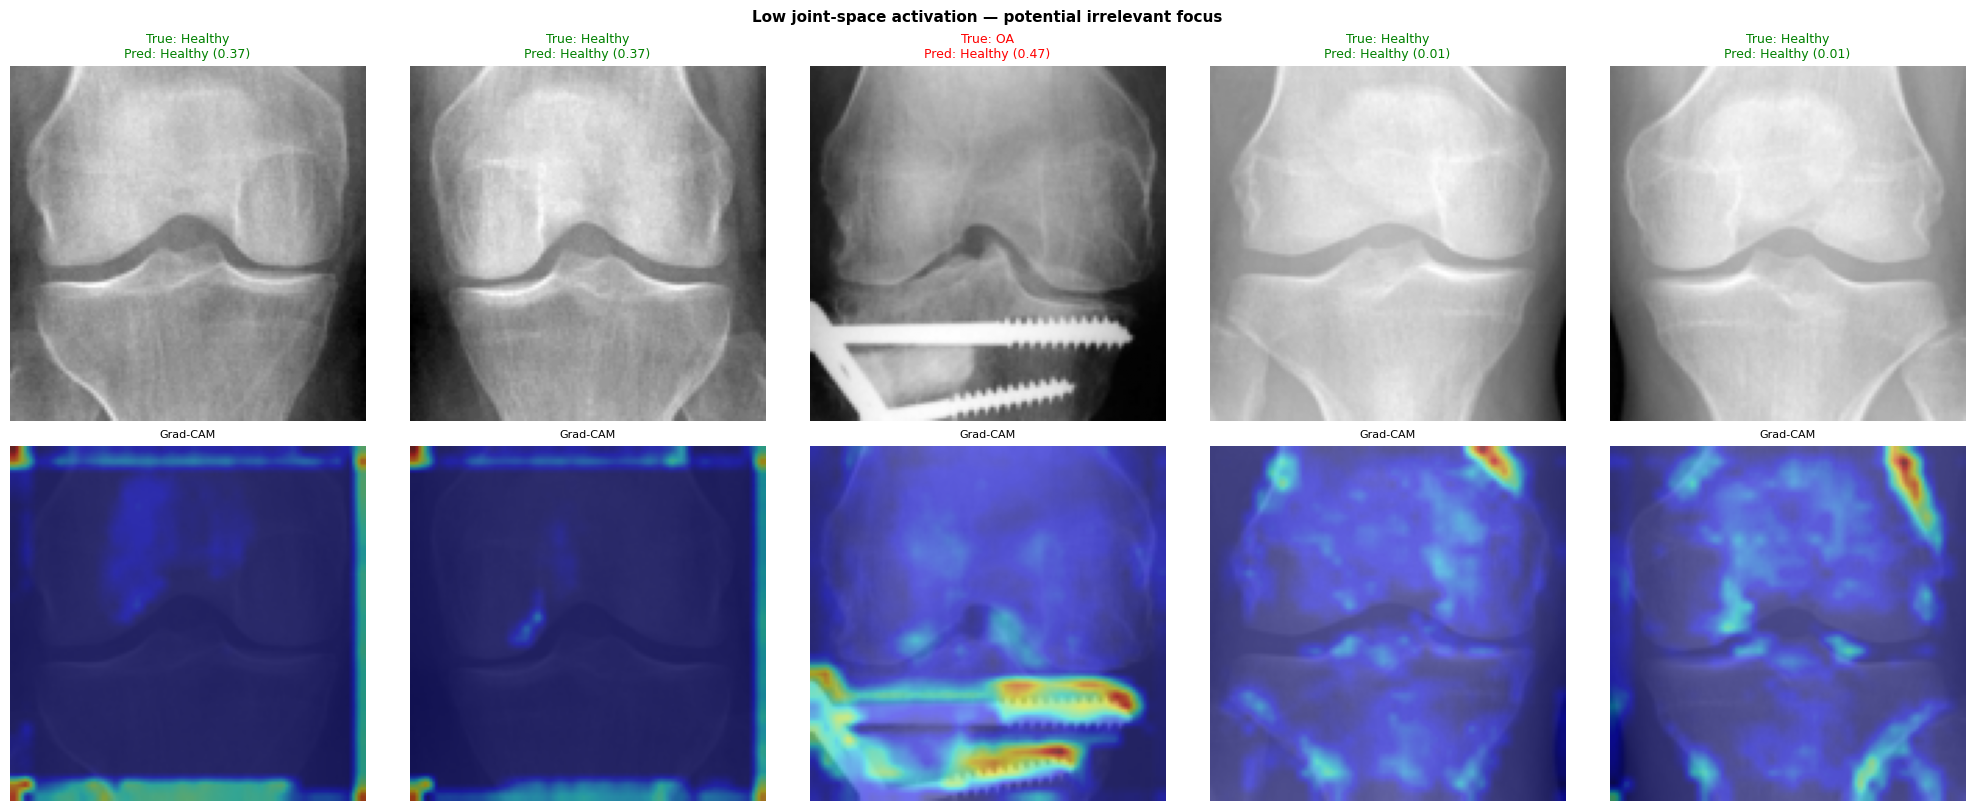

In [ ]:
# Images where the model focuses LEAST on the joint space (possible irrelevant structures)
low_center_idx = np.argsort(center_frac_arr)[:6]
print(
    "Central-band fractions for lowest-focus images:",
    center_frac_arr[low_center_idx].round(3),
)
show_gradcam(
    low_center_idx,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Low joint-space activation — potential irrelevant focus",
)

# 5. Limitations of Grad-CAM

While Grad-CAM provides useful intuition about where the model looks, several fundamental limitations must be kept in mind:

1. **Coarse spatial resolution.** Grad-CAM heatmaps are produced at the resolution of the target convolutional feature map (32 × 32 here) and bilinearly upsampled to 128 × 128. Fine-grained structures such as the joint-space width or small osteophytes are far below this resolution — the method cannot localise them precisely.

2. **Post-hoc rationalisation.** Grad-CAM explains the gradient signal at inference time, not the actual decision rule the model learned during training. A heatmap that highlights the joint space does *not* prove the model uses the joint space correctly; it only shows which pixels shifted the output most for that single image.

3. **Gradient saturation / noise.** In regions where activations are already near their maximum, gradients vanish (saturation), causing Grad-CAM to understate their importance. This can make biologically relevant areas appear less prominent than they are.

4. **No counterfactual grounding.** Grad-CAM tells us where the model is sensitive, but not what it would predict if that region were masked. The highlighted region could be a proxy feature (e.g., patient age visible as bone density) rather than the intended diagnostic feature.

5. **Confirmation-bias risk.** A heatmap that plausibly covers the joint space may look clinically convincing even when the model achieved that focus by coincidence or for the wrong reasons. Quantitative statistics (central-band fraction, CoM) help guard against purely visual over-interpretation, but the numbers here show that the model's focus is only marginally better than chance.

In summary, Grad-CAM is a useful *exploratory* tool but should not be used as evidence that a model has learned clinically sound reasoning. Complementary approaches — such as attention supervision, segmentation-guided training, or ablation studies — are needed to verify that clinically relevant regions are truly driving predictions.
